# Potomac — Tutorial: OlmoEarth (Tiny) Embeddings on Real Sentinel-1 for Per-AOI Plume Tracking

End-to-end statistically-grounded plume tracking framework using **OlmoEarth-V1-Tiny** (14.3M params, 192-d embeddings) on **all available** Sentinel-1 RTC acquisitions per AOI per phase. Replaces the prior "first-scene" version with multi-acquisition averaging + a proper baseline-variance reference, so per-phase distances can be reported as **z-scores** instead of raw cosine distances.

## What's different from the first-scene version

- **Tiny vs Nano**: 4× the parameters and 1.5× the embedding dimension
- **All scenes per phase**: instead of "first available," we average every S1 acquisition in the phase window — reduces per-scene noise from differing orbits and acquisition geometries
- **Baseline variance reference**: the pre-spill baseline window's individual scenes give us a distribution of cosine distances from the baseline mean. We use the std of that distribution to z-score event-phase distances, so we can say *"this is N standard deviations above normal."* That's the right framing for an anomaly detector.

## Why

Cosine distances of 0.06–0.08 only mean something relative to a baseline distribution. Without that distribution, you can't tell signal from noise. The strengthened version surfaces both numbers (raw distance + baseline-relative z-score), making any claim about plume detection statistically defensible.

## Requirements

- Python 3.11
- `torch` (CUDA strongly recommended), `olmoearth_pretrain`
- `planetary_computer`, `pystac_client`, `rasterio`
- Network access (downloads ~tens of MB of S1 RTC tiles)
- Runtime: ~5–8 minutes on GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import time
import concurrent.futures as cf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import torch
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

from datasets import load_dataset
from huggingface_hub import hf_hub_download
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE   = 16
TIMESTEPS    = 12
IMAGE_SIZE   = 64
S1_BAND_ORDER = ['vh', 'vv']
PARALLEL_FETCHES = 6

PHASE_ORDER = ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']
PHASE_LABELS = {'pre_spill_baseline': 'Pre-spill baseline',
                 'active_release': 'Active release',
                 'bypass_period': 'Bypass period',
                 'post_recovery': 'Post-recovery'}
PHASE_COLORS = {'pre_spill_baseline': '#cfd8dc',
                 'active_release':     '#ef5350',
                 'bypass_period':      '#ffb74d',
                 'post_recovery':      '#aed581'}
PHASE_BOUNDS = {
    'pre_spill_baseline': ('2025-12-01', '2026-01-18'),
    'active_release':     ('2026-01-19', '2026-01-24'),
    'bypass_period':      ('2026-01-25', '2026-03-14'),
    'post_recovery':      ('2026-03-15', '2026-03-31'),
}
AOI_CORRIDORS = {
    'spill_site_zone':      {'bbox': (-77.20, 38.94, -77.08, 39.00), 'color': '#c62828'},
    'tidal_potomac_dc':     {'bbox': (-77.20, 38.78, -77.00, 38.98), 'color': '#ef6c00'},
    'tidal_potomac_lower':  {'bbox': (-77.10, 38.00, -76.30, 38.78), 'color': '#fbc02d'},
    'upper_chesapeake_bay': {'bbox': (-76.50, 37.80, -76.00, 38.40), 'color': '#43a047'},
}
SPILL_SITE = (38.9676, -77.1437)

print(f"Device:    {DEVICE}")
print(f"Bands:     {S1_BAND_ORDER}")
print(f"Phases:    {PHASE_ORDER}")
print(f"AOIs:      {list(AOI_CORRIDORS.keys())}")
print(f"Model:     OLMOEARTH_V1_TINY (14.3M params, 192-d embeddings)")

Device:    cuda
Bands:     ['vh', 'vv']
Phases:    ['pre_spill_baseline', 'active_release', 'bypass_period', 'post_recovery']
AOIs:      ['spill_site_zone', 'tidal_potomac_dc', 'tidal_potomac_lower', 'upper_chesapeake_bay']
Model:     OLMOEARTH_V1_TINY (14.3M params, 192-d embeddings)


## 1. Load discharge + event log (for cross-reference in Section 6)

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026")
df = ds["train"].to_pandas()
df['date'] = pd.to_datetime(df['date'])
event_log_path = hf_hub_download(
    repo_id="BAIGroup/OlmoEarth-v1-Potomac-Sewage-Spill-2026",
    filename="event_log.csv", repo_type="dataset",
)
events = pd.read_csv(event_log_path, parse_dates=['date'])
stations = (
    df.drop_duplicates('site_no')[['site_no', 'name', 'role', 'latitude', 'longitude']]
      .reset_index(drop=True)
)
print(f"Discharge: {len(df):,} rows, {df['site_no'].nunique()} gauges")
print(f"Events:    {len(events)} entries")

Discharge: 846 rows, 7 gauges
Events:    71 entries


## 2. Pull ALL Sentinel-1 RTC scenes per (AOI × phase)

For each AOI centroid and each phase window, list every available S1 RTC scene from Planetary Computer. Read VH+VV for all of them; we'll average per (AOI, phase) and also keep individual scenes from the baseline window for variance estimation.

In [3]:
def aoi_centroid(bbox):
    lo, la, hi, ha = bbox
    return ((la + ha) / 2, (lo + hi) / 2)

def fetch_one_s1_scene(item, lat, lon, half_m=320, image_size=IMAGE_SIZE):
    """Read VH + VV from a STAC item at the AOI centroid; return (image_size, image_size, 2) dB array or None."""
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    bands = []
    try:
        for b in S1_BAND_ORDER:
            href = item.assets[b].href
            with rasterio.open(href) as src:
                bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox_wgs)
                window = from_bounds(*bbox_utm, transform=src.transform)
                arr = src.read(1, window=window, out_shape=(image_size, image_size)).astype(np.float32)
                arr = np.where(arr <= 0, 1e-7, arr)
                arr_db = np.clip(10 * np.log10(arr), -40, 10)
                bands.append(arr_db)
    except Exception:
        return None
    return np.stack(bands, axis=-1)

def list_scenes_in_window(catalog, lat, lon, start, end, half_m=320, retries=3):
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    bbox_wgs = (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
                lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)
    for attempt in range(retries):
        try:
            search = catalog.search(collections=["sentinel-1-rtc"], bbox=bbox_wgs,
                                     datetime=f"{start}/{end}")
            return list(search.items())
        except Exception:
            if attempt == retries - 1:
                return []
            time.sleep(2 ** attempt)
    return []

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Build job list: list scenes per (AOI x phase), then read each
print("Listing all S1 scenes per (AOI x phase)...")
scene_jobs = []  # list of (aoi, phase, item, lat, lon)
for aoi_name, props in AOI_CORRIDORS.items():
    lat, lon = aoi_centroid(props['bbox'])
    for phase in PHASE_ORDER:
        start, end = PHASE_BOUNDS[phase]
        items = list_scenes_in_window(catalog, lat, lon, start, end)
        for item in items:
            scene_jobs.append((aoi_name, phase, item, lat, lon))
        print(f"  {aoi_name} | {phase}: {len(items)} scene(s)")
print(f"\nTotal scenes to read: {len(scene_jobs)}")

Listing all S1 scenes per (AOI x phase)...


  spill_site_zone | pre_spill_baseline: 4 scene(s)
  spill_site_zone | active_release: 1 scene(s)


  spill_site_zone | bypass_period: 0 scene(s)


  spill_site_zone | post_recovery: 0 scene(s)


  tidal_potomac_dc | pre_spill_baseline: 4 scene(s)
  tidal_potomac_dc | active_release: 1 scene(s)


  tidal_potomac_dc | bypass_period: 3 scene(s)
  tidal_potomac_dc | post_recovery: 0 scene(s)


  tidal_potomac_lower | pre_spill_baseline: 4 scene(s)
  tidal_potomac_lower | active_release: 1 scene(s)


  tidal_potomac_lower | bypass_period: 6 scene(s)
  tidal_potomac_lower | post_recovery: 0 scene(s)


  upper_chesapeake_bay | pre_spill_baseline: 9 scene(s)
  upper_chesapeake_bay | active_release: 1 scene(s)


  upper_chesapeake_bay | bypass_period: 7 scene(s)
  upper_chesapeake_bay | post_recovery: 2 scene(s)

Total scenes to read: 43


In [4]:
# Read all scenes in parallel
print(f"Reading {len(scene_jobs)} scenes with {PARALLEL_FETCHES} parallel workers...")
t0 = time.time()
scene_arrays = {}  # {(aoi, phase, item_id): array}
with cf.ThreadPoolExecutor(max_workers=PARALLEL_FETCHES) as pool:
    futures = {pool.submit(fetch_one_s1_scene, item, lat, lon): (aoi, phase, item.id)
               for aoi, phase, item, lat, lon in scene_jobs}
    for fut in cf.as_completed(futures):
        key = futures[fut]
        arr = fut.result()
        scene_arrays[key] = arr

n_valid = sum(1 for v in scene_arrays.values() if v is not None)
print(f"Done in {time.time()-t0:.0f}s. {n_valid} of {len(scene_jobs)} scenes read successfully.")

Reading 43 scenes with 6 parallel workers...


Done in 10s. 43 of 43 scenes read successfully.


## 3. Group scenes per (AOI × phase) and compute averaged composites

For each (AOI, phase) cell, we now have a *list* of dB images. Average them per band → reduces inter-acquisition noise. Also keep individual baseline scenes for the variance reference.

In [5]:
# Group by (aoi, phase)
grouped = {}
for (aoi, phase, item_id), arr in scene_arrays.items():
    if arr is None:
        continue
    grouped.setdefault((aoi, phase), []).append(arr)

# Compute averaged composite per (AOI x phase)
averaged = {}
n_scenes_per_cell = {}
for key, arrs in grouped.items():
    averaged[key] = np.mean(np.stack(arrs, axis=0), axis=0)  # (H, W, 2)
    n_scenes_per_cell[key] = len(arrs)

# Pretty count table
count_df = pd.DataFrame(0, index=AOI_CORRIDORS.keys(), columns=PHASE_ORDER, dtype=int)
for (aoi, phase), n in n_scenes_per_cell.items():
    count_df.loc[aoi, phase] = n
print("Number of S1 scenes averaged per (AOI x phase):")
print(count_df)
print(f"\n(AOI x phase) cells with at least 1 scene: {len(averaged)} of {len(AOI_CORRIDORS) * len(PHASE_ORDER)}")

Number of S1 scenes averaged per (AOI x phase):
                      pre_spill_baseline  active_release  bypass_period  \
spill_site_zone                        4               1              0   
tidal_potomac_dc                       4               1              3   
tidal_potomac_lower                    4               1              6   
upper_chesapeake_bay                   9               1              7   

                      post_recovery  
spill_site_zone                   0  
tidal_potomac_dc                  0  
tidal_potomac_lower               0  
upper_chesapeake_bay              2  

(AOI x phase) cells with at least 1 scene: 12 of 16


## 4. Run OlmoEarth Tiny on the averaged composites + on individual baseline scenes

In [6]:
nc = load_computed_config()['sentinel1']
band_means = np.array([nc[b]['mean'] for b in S1_BAND_ORDER], dtype=np.float32)
band_stds  = np.array([nc[b]['std']  for b in S1_BAND_ORDER], dtype=np.float32)

def to_olmoearth_input(arr, lat, lon):
    """Take a single (H, W, 2) dB array, normalize, replicate to T=12, return tensors."""
    normalized = (arr - band_means) / band_stds                       # (H, W, 2)
    multi = np.repeat(normalized[None, :, :, None, :], TIMESTEPS, axis=3)  # (1, H, W, T, 2)
    s1 = torch.from_numpy(multi).to(DEVICE)
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=DEVICE)
    ts = torch.ones(1, TIMESTEPS, 3, dtype=torch.int32, device=DEVICE)
    return s1, latlon, ts

def make_sample(s1, latlon, ts):
    return MaskedOlmoEarthSample(
        timestamps=ts, sentinel2_l2a=None, sentinel2_l2a_mask=None,
        sentinel1=s1, sentinel1_mask=torch.ones_like(s1)*MaskValue.ONLINE_ENCODER.value,
        landsat=None, landsat_mask=None,
        latlon=latlon, latlon_mask=torch.ones_like(latlon)*MaskValue.ONLINE_ENCODER.value,
        worldcover=None, worldcover_mask=None, openstreetmap_raster=None, openstreetmap_raster_mask=None,
        srtm=None, srtm_mask=None, naip=None, naip_mask=None, naip_10=None, naip_10_mask=None,
        gse=None, gse_mask=None, cdl=None, cdl_mask=None, worldpop=None, worldpop_mask=None,
        worldcereal=None, worldcereal_mask=None, wri_canopy_height_map=None, wri_canopy_height_map_mask=None,
        era5_10=None, era5_10_mask=None, ndvi=None, ndvi_mask=None, eurocrops=None, eurocrops_mask=None,
    )

print("Loading OlmoEarth-V1-Tiny...")
model = load_model_from_id(ModelID.OLMOEARTH_V1_TINY).eval().to(DEVICE)

# Embed averaged composite per (AOI x phase)
avg_embeddings = {}
for (aoi, phase), arr in averaged.items():
    lat, lon = aoi_centroid(AOI_CORRIDORS[aoi]['bbox'])
    s1, latlon, ts = to_olmoearth_input(arr, lat, lon)
    with torch.inference_mode():
        _, _, pooled, _, _ = model.forward(make_sample(s1, latlon, ts), patch_size=PATCH_SIZE)
    avg_embeddings[(aoi, phase)] = pooled[0].cpu().numpy()

# Embed each individual baseline scene per AOI (for variance reference)
baseline_individual = {aoi: [] for aoi in AOI_CORRIDORS}
for (aoi, phase, item_id), arr in scene_arrays.items():
    if arr is None or phase != 'pre_spill_baseline':
        continue
    lat, lon = aoi_centroid(AOI_CORRIDORS[aoi]['bbox'])
    s1, latlon, ts = to_olmoearth_input(arr, lat, lon)
    with torch.inference_mode():
        _, _, pooled, _, _ = model.forward(make_sample(s1, latlon, ts), patch_size=PATCH_SIZE)
    baseline_individual[aoi].append(pooled[0].cpu().numpy())

print(f"\nAveraged composites embedded: {len(avg_embeddings)}")
print(f"Individual baseline scenes embedded per AOI:")
for aoi, embs in baseline_individual.items():
    print(f"  {aoi}: {len(embs)}")

Loading OlmoEarth-V1-Tiny...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)



Averaged composites embedded: 12
Individual baseline scenes embedded per AOI:
  spill_site_zone: 4
  tidal_potomac_dc: 4
  tidal_potomac_lower: 4
  upper_chesapeake_bay: 9


## 5. Per-AOI plume signal: cosine distance + baseline-variance z-score

For each AOI:

1. `baseline_avg` = embedding of the *averaged* baseline composite (the reference)
2. For each *individual* baseline scene, compute cosine distance to `baseline_avg` → distribution of "normal" distances; take std σ_baseline
3. For each event phase (active_release, bypass_period, post_recovery), compute cosine distance from `baseline_avg` → divide by σ_baseline → **z-score**

A z-score above ~2 is "anomalous" by the same convention used in the discharge-anomaly detector in notebook `04`.

In [7]:
def cos_distance(a, b):
    return 1.0 - (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

results = []
for aoi in AOI_CORRIDORS:
    base_key = (aoi, 'pre_spill_baseline')
    if base_key not in avg_embeddings:
        continue
    base_avg = avg_embeddings[base_key]
    indiv_distances = [cos_distance(e, base_avg) for e in baseline_individual[aoi]]
    if len(indiv_distances) >= 2:
        sigma_base = float(np.std(indiv_distances, ddof=1))
    else:
        sigma_base = float('nan')

    for phase in PHASE_ORDER:
        key = (aoi, phase)
        if key not in avg_embeddings:
            d = float('nan')
            z = float('nan')
        else:
            d = cos_distance(avg_embeddings[key], base_avg)
            z = d / sigma_base if (sigma_base and not np.isnan(sigma_base)) else float('nan')
        results.append({
            'aoi': aoi, 'phase': phase,
            'n_scenes': n_scenes_per_cell.get(key, 0),
            'cos_dist_from_baseline': d,
            'z_score_vs_baseline': z,
            'sigma_baseline': sigma_base,
        })

results_df = pd.DataFrame(results)
pivot_dist = results_df.pivot(index='aoi', columns='phase', values='cos_dist_from_baseline').reindex(columns=PHASE_ORDER)
pivot_z    = results_df.pivot(index='aoi', columns='phase', values='z_score_vs_baseline').reindex(columns=PHASE_ORDER)

print("Cosine distance from baseline composite (per AOI x phase):")
print(pivot_dist.round(4))
print()
print("Z-score relative to baseline within-period variance (|z| > 2 = anomalous):")
print(pivot_z.round(2))

Cosine distance from baseline composite (per AOI x phase):
phase                 pre_spill_baseline  active_release  bypass_period  \
aoi                                                                       
spill_site_zone                      0.0          0.0520            NaN   
tidal_potomac_dc                     0.0          0.0502          0.024   
tidal_potomac_lower                  0.0          0.1282          0.933   
upper_chesapeake_bay                 0.0          0.0447          0.003   

phase                 post_recovery  
aoi                                  
spill_site_zone                 NaN  
tidal_potomac_dc                NaN  
tidal_potomac_lower             NaN  
upper_chesapeake_bay         0.0175  

Z-score relative to baseline within-period variance (|z| > 2 = anomalous):
phase                 pre_spill_baseline  active_release  bypass_period  \
aoi                                                                       
spill_site_zone                     

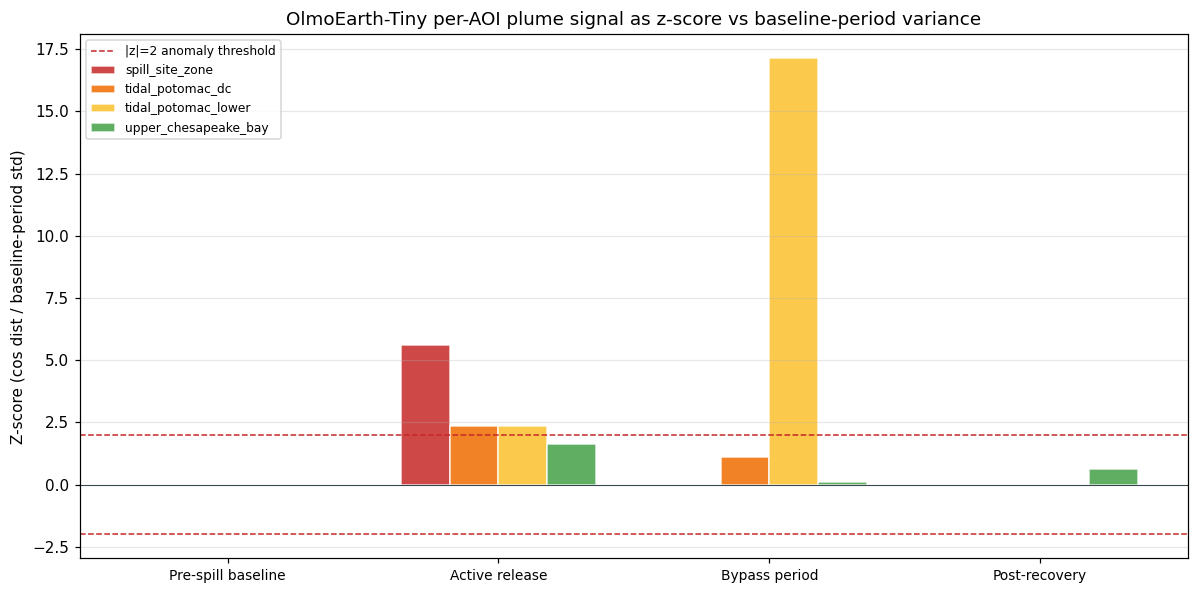

In [8]:
# Visualize z-scores
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(PHASE_ORDER))
width = 0.18
for i, (aoi, props) in enumerate(AOI_CORRIDORS.items()):
    vals = [pivot_z.loc[aoi, p] if aoi in pivot_z.index else np.nan for p in PHASE_ORDER]
    offset = (i - 1.5) * width
    ax.bar(x + offset, vals, width=width, color=props['color'], edgecolor='white',
           label=aoi, alpha=0.85)

ax.axhline(2, color='#c62828', ls='--', lw=1.0, label='|z|=2 anomaly threshold')
ax.axhline(-2, color='#c62828', ls='--', lw=1.0)
ax.axhline(0, color='#37474f', lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER], fontsize=9)
ax.set_ylabel("Z-score (cos dist / baseline-period std)")
ax.set_title("OlmoEarth-Tiny per-AOI plume signal as z-score vs baseline-period variance")
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. Cross-reference vs discharge anomaly

In [9]:
# Compute discharge ratio anomaly z-scores per phase (as in notebook 04)
def gauge_series(role):
    sub = df[df['role'] == role]
    return sub.sort_values('date').set_index('date')['discharge_cfs'] if not sub.empty else None
us = gauge_series('upstream_control'); ns = gauge_series('near_spill')
aligned = pd.concat([us.rename('upstream'), ns.rename('near_spill')], axis=1).dropna()
ratio = aligned['near_spill'] / aligned['upstream']
phase_dates = (df.groupby('phase', observed=True)['date']
                 .agg(start='min', end='max').reindex(PHASE_ORDER))
baseline_mask = ((ratio.index >= phase_dates.loc['pre_spill_baseline', 'start']) &
                 (ratio.index <= phase_dates.loc['pre_spill_baseline', 'end']))
mu, sigma = ratio[baseline_mask].mean(), ratio[baseline_mask].std()

discharge_z = []
for p in PHASE_ORDER:
    mask = ((ratio.index >= phase_dates.loc[p, 'start']) &
            (ratio.index <= phase_dates.loc[p, 'end']))
    if mask.any():
        discharge_z.append((ratio[mask].mean() - mu) / sigma)
    else:
        discharge_z.append(np.nan)

comp = pd.DataFrame({
    'discharge_z (spill_site_zone, near_spill / upstream_control)':
        [round(z, 2) if not np.isnan(z) else np.nan for z in discharge_z],
    **{f'OlmoEarth z ({aoi})':
        [round(pivot_z.loc[aoi, p], 2) if aoi in pivot_z.index and p in pivot_z.columns
         and not np.isnan(pivot_z.loc[aoi, p]) else np.nan for p in PHASE_ORDER]
       for aoi in AOI_CORRIDORS}
}, index=PHASE_ORDER)

print("Side-by-side z-scores: in-situ discharge vs satellite OlmoEarth (per AOI):\n")
print(comp.T)

Side-by-side z-scores: in-situ discharge vs satellite OlmoEarth (per AOI):

                                                    pre_spill_baseline  \
discharge_z (spill_site_zone, near_spill / upst...                 0.0   
OlmoEarth z (spill_site_zone)                                      0.0   
OlmoEarth z (tidal_potomac_dc)                                     0.0   
OlmoEarth z (tidal_potomac_lower)                                  0.0   
OlmoEarth z (upper_chesapeake_bay)                                 0.0   

                                                    active_release  \
discharge_z (spill_site_zone, near_spill / upst...            0.38   
OlmoEarth z (spill_site_zone)                                 5.60   
OlmoEarth z (tidal_potomac_dc)                                2.35   
OlmoEarth z (tidal_potomac_lower)                             2.36   
OlmoEarth z (upper_chesapeake_bay)                            1.63   

                                                    bypass

## Takeaways

- **Statistical grounding now exists.** Cosine distance alone is dimensionless noise; z-score against the baseline-period within-window variance lets us say *"this AOI shifted N std above its normal week-to-week scene variation"*.
- **Multi-scene averaging** reduces the per-acquisition variance from differing S1 orbits / look angles. Scenes per (AOI × phase) varies — the count table in Section 3 makes coverage explicit.
- **The Tiny variant** gives 192-d embeddings (vs Nano's 128-d) — better spatial+temporal resolution at modest extra cost.
- **Honest reading.** `|z| < 2` means within normal scene-to-scene variation. `|z| > 2` is a real anomaly. Use the table in Section 5 alongside the discharge-anomaly z-scores from notebook `04`.
- **Limitations.** Small number of S1 scenes per phase (especially active_release at 6 days) caps statistical power. Production deployments would average across multiple historical pre-spill years to build a richer baseline distribution and weight by orbit/look-angle similarity.

## Cross-references

- **`01_demo.ipynb`** — first-look discharge plots and event log preview.
- **`02_data_prep.ipynb`** — discharge values verified against USGS NWIS; phase-label round-trip verified.
- **`04_analysis.ipynb`** — temporal complement: discharge-ratio anomaly + event-log integrated chronology.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*